In [62]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error

In [58]:
student_performance = pd.read_csv("StudentPerformanceFactors.csv")

student_performance.head(10)

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70
5,19,88,Medium,Medium,Yes,8,89,Medium,Yes,3,Medium,Medium,Public,Positive,3,No,Postgraduate,Near,Male,71
6,29,84,Medium,Low,Yes,7,68,Low,Yes,1,Low,Medium,Private,Neutral,2,No,High School,Moderate,Male,67
7,25,78,Low,High,Yes,6,50,Medium,Yes,1,High,High,Public,Negative,2,No,High School,Far,Male,66
8,17,94,Medium,High,No,6,80,High,Yes,0,Medium,Low,Private,Neutral,1,No,College,Near,Male,69
9,23,98,Medium,Medium,Yes,8,71,Medium,Yes,0,High,High,Public,Positive,5,No,High School,Moderate,Male,72


In [4]:
df = student_performance.copy()


In [6]:
df.shape

(6607, 20)

In [7]:
df.duplicated().sum()   # There are no duplicated values

df.isnull().sum() # There are 78 - Teacher_Quality, 90 - Parental_Education_Level  and 67 - Distance_from_Home


Hours_Studied                  0
Attendance                     0
Parental_Involvement           0
Access_to_Resources            0
Extracurricular_Activities     0
Sleep_Hours                    0
Previous_Scores                0
Motivation_Level               0
Internet_Access                0
Tutoring_Sessions              0
Family_Income                  0
Teacher_Quality               78
School_Type                    0
Peer_Influence                 0
Physical_Activity              0
Learning_Disabilities          0
Parental_Education_Level      90
Distance_from_Home            67
Gender                         0
Exam_Score                     0
dtype: int64

In [8]:
df.describe()

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6607.000000,6607.000000,6607.00000,6607.000000,6607.000000,6607.000000,6607.000000
mean,19.975329,79.977448,7.02906,75.070531,1.493719,2.967610,67.235659
std,5.990594,11.547475,1.46812,14.399784,1.230570,1.031231,3.890456
min,1.000000,60.000000,4.00000,50.000000,0.000000,0.000000,55.000000
25%,16.000000,70.000000,6.00000,63.000000,1.000000,2.000000,65.000000
50%,20.000000,80.000000,7.00000,75.000000,1.000000,3.000000,67.000000
75%,24.000000,90.000000,8.00000,88.000000,2.000000,4.000000,69.000000
max,44.000000,100.000000,10.00000,100.000000,8.000000,6.000000,101.000000


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6607 non-null   int64 
 1   Attendance                  6607 non-null   int64 
 2   Parental_Involvement        6607 non-null   object
 3   Access_to_Resources         6607 non-null   object
 4   Extracurricular_Activities  6607 non-null   object
 5   Sleep_Hours                 6607 non-null   int64 
 6   Previous_Scores             6607 non-null   int64 
 7   Motivation_Level            6607 non-null   object
 8   Internet_Access             6607 non-null   object
 9   Tutoring_Sessions           6607 non-null   int64 
 10  Family_Income               6607 non-null   object
 11  Teacher_Quality             6529 non-null   object
 12  School_Type                 6607 non-null   object
 13  Peer_Influence              6607 non-null   obje

In [10]:
df["Teacher_Quality"].describe()

count       6529
unique         3
top       Medium
freq        3925
Name: Teacher_Quality, dtype: object

<Axes: xlabel='Teacher_Quality', ylabel='Exam_Score'>

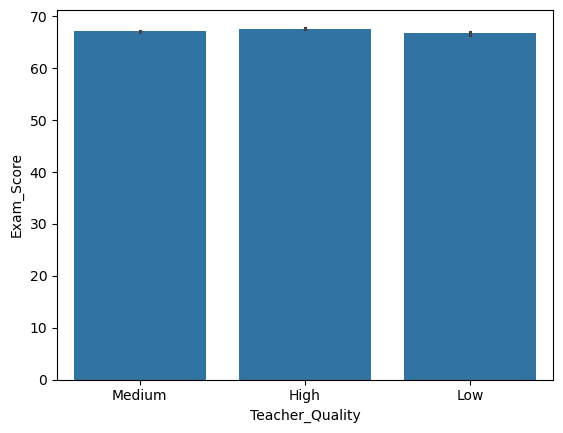

In [11]:
sns.barplot(data = df , x="Teacher_Quality" , y="Exam_Score")

In [59]:
# Based on the visualization analysis, rows with missing Teacher_Quality values were removed due to their low impact on Exam_Score and the small number of missing records.

df = df.dropna(subset=["Teacher_Quality"])

df.isnull().sum()

# Teacher_Quality contains three ordinal categories (Low, Medium, High), which are mapped to numerical values for model training.

df["Teacher_Quality"] = df["Teacher_Quality"].map({"Low": 0 , "Medium": 1 , "High": 2}) 

In [68]:
df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,Peer_Influence,Physical_Activity,Learning_Disabilities,Distance_from_Home,Exam_Score,Parental_Education_Level_High School,Parental_Education_Level_Postgraduate,Gender_Female,School_Type_Public
0,23,84,0,2,0,73,0,1,0,0,NaN,2,3,0,0,67,1,0,0,1
1,19,64,0,1,0,59,0,1,2,1,NaN,0,4,0,1,61,0,0,1,1
2,24,98,1,1,1,91,1,1,2,1,NaN,1,4,0,0,74,0,1,0,1
3,29,89,0,1,1,98,1,1,1,1,NaN,0,4,0,1,71,1,0,0,1
4,19,92,1,1,1,65,1,1,3,1,NaN,1,4,0,0,70,0,0,1,1


In [14]:
df["Parental_Education_Level"].describe()

count            6443
unique              3
top       High School
freq             3188
Name: Parental_Education_Level, dtype: object

<Axes: xlabel='Parental_Education_Level', ylabel='Exam_Score'>

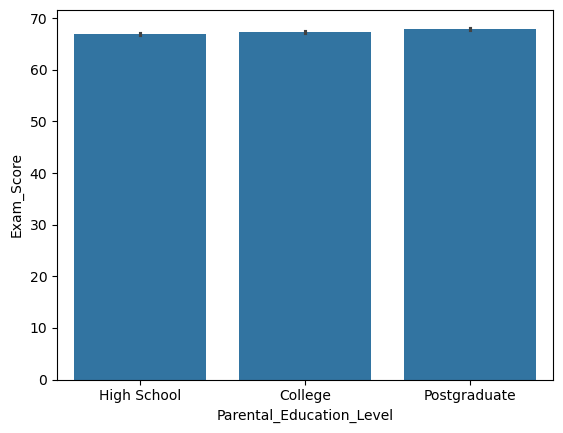

In [15]:
sns.barplot(data = df , x = "Parental_Education_Level" , y = "Exam_Score")

In [17]:
df["Distance_from_Home"].describe()

count     6464
unique       3
top       Near
freq      3849
Name: Distance_from_Home, dtype: object

<Axes: xlabel='Distance_from_Home', ylabel='Exam_Score'>

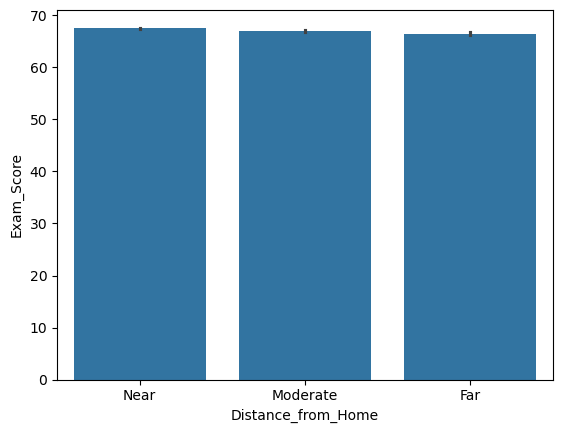

In [18]:
sns.barplot(data = df , x = "Distance_from_Home" , y = "Exam_Score")

In [19]:
# Removed rows with missing Distance_from_Home values, as they represented only a small percentage of the dataset.

df = df.dropna(subset=["Distance_from_Home"])

df["Distance_from_Home"] = df["Distance_from_Home"].map({"Near": 0 , "Moderate": 1 , "Far" : 2})

In [67]:
df.head(10)

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,Peer_Influence,Physical_Activity,Learning_Disabilities,Distance_from_Home,Exam_Score,Parental_Education_Level_High School,Parental_Education_Level_Postgraduate,Gender_Female,School_Type_Public
0,23,84,0,2,0,73,0,1,0,0,NaN,2,3,0,0,67,1,0,0,1
1,19,64,0,1,0,59,0,1,2,1,NaN,0,4,0,1,61,0,0,1,1
2,24,98,1,1,1,91,1,1,2,1,NaN,1,4,0,0,74,0,1,0,1
3,29,89,0,1,1,98,1,1,1,1,NaN,0,4,0,1,71,1,0,0,1
4,19,92,1,1,1,65,1,1,3,1,NaN,1,4,0,0,70,0,0,1,1
5,19,88,1,1,1,89,1,1,3,1,NaN,2,3,0,0,71,0,1,0,1
6,29,84,1,0,1,68,0,1,1,0,NaN,1,2,0,1,67,1,0,0,0
7,25,78,0,2,1,50,1,1,1,2,NaN,0,2,0,2,66,1,0,0,1
8,17,94,1,2,0,80,2,1,0,1,NaN,1,1,0,0,69,0,0,0,0
9,23,98,1,1,1,71,1,1,0,2,NaN,2,5,0,1,72,1,0,0,1


In [21]:
df.dtypes

Hours_Studied                  int64
Attendance                     int64
Parental_Involvement          object
Access_to_Resources           object
Extracurricular_Activities    object
Sleep_Hours                    int64
Previous_Scores                int64
Motivation_Level              object
Internet_Access               object
Tutoring_Sessions              int64
Family_Income                 object
Teacher_Quality                int64
School_Type                   object
Peer_Influence                object
Physical_Activity              int64
Learning_Disabilities         object
Parental_Education_Level      object
Distance_from_Home             int64
Gender                        object
Exam_Score                     int64
dtype: object

In [22]:
df["Parental_Education_Level"] = student_performance["Parental_Education_Level"]

In [23]:
df["Parental_Education_Level"] = student_performance["Parental_Education_Level"]
df["Parental_Education_Level"]

df = df.dropna(subset=["Parental_Education_Level"])

df = pd.get_dummies(df, columns=["Parental_Education_Level"] , drop_first= True , dtype = int)

df.head(10)


,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,...,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Distance_from_Home,Gender,Exam_Score,Parental_Education_Level_High School,Parental_Education_Level_Postgraduate
0,23,84,Low,High,No,7,73,Low,Yes,0,...,1,Public,Positive,3,No,0,Male,67,1,0
1,19,64,Low,Medium,No,8,59,Low,Yes,2,...,1,Public,Negative,4,No,1,Female,61,0,0
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,...,1,Public,Neutral,4,No,0,Male,74,0,1
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,...,1,Public,Negative,4,No,1,Male,71,1,0
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,...,2,Public,Neutral,4,No,0,Female,70,0,0
5,19,88,Medium,Medium,Yes,8,89,Medium,Yes,3,...,1,Public,Positive,3,No,0,Male,71,0,1
6,29,84,Medium,Low,Yes,7,68,Low,Yes,1,...,1,Private,Neutral,2,No,1,Male,67,1,0
7,25,78,Low,High,Yes,6,50,Medium,Yes,1,...,2,Public,Negative,2,No,2,Male,66,1,0
8,17,94,Medium,High,No,6,80,High,Yes,0,...,0,Private,Neutral,1,No,0,Male,69,0,0
9,23,98,Medium,Medium,Yes,8,71,Medium,Yes,0,...,2,Public,Positive,5,No,1,Male,72,1,0


In [24]:
df.head(10)
df = df.drop(columns=["Parental_Education_Level_High School" , "Parental_Education_Level_Postgraduate", "Parental_Education_Level_High School" , "Parental_Education_Level_Postgraduate"])

In [25]:
# One Hot Encoding

df = pd.get_dummies(df , columns=["Gender"] , dtype = int)

In [27]:
# Parental_Involvement Categorial Encoding

df["Parental_Involvement"] = df["Parental_Involvement"].map({"Low" : 0 , "Medium" : 1, "High" : 2})

df

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,...,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Distance_from_Home,Exam_Score,Parental_Education_Level_High School,Parental_Education_Level_Postgraduate,Gender_Female,Gender_Male
0,23,84,0,High,No,7,73,Low,Yes,0,...,Public,Positive,3,No,0,67,1,0,0,1
1,19,64,0,Medium,No,8,59,Low,Yes,2,...,Public,Negative,4,No,1,61,0,0,1,0
2,24,98,1,Medium,Yes,7,91,Medium,Yes,2,...,Public,Neutral,4,No,0,74,0,1,0,1
3,29,89,0,Medium,Yes,8,98,Medium,Yes,1,...,Public,Negative,4,No,1,71,1,0,0,1
4,19,92,1,Medium,Yes,6,65,Medium,Yes,3,...,Public,Neutral,4,No,0,70,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6602,25,69,2,Medium,No,7,76,Medium,Yes,1,...,Public,Positive,2,No,0,68,1,0,1,0
6603,23,76,2,Medium,No,8,81,Medium,Yes,3,...,Public,Positive,2,No,0,69,1,0,1,0
6604,20,90,1,Low,Yes,6,65,Low,Yes,3,...,Public,Negative,2,No,0,68,0,1,1,0
6605,10,86,2,High,Yes,6,91,High,Yes,2,...,Private,Positive,3,No,2,68,1,0,1,0


In [28]:
df["Parental_Involvement"].unique()

array([0, 1, 2])

In [29]:
df["Access_to_Resources"] = df["Access_to_Resources"].map({"Low" : 0 , "Medium" : 1, "High" : 2})

In [30]:
df["Extracurricular_Activities"] = df["Extracurricular_Activities"].map({"No" : 0 , "Yes" : 1})

In [31]:
df["Learning_Disabilities"] = df["Learning_Disabilities"].map({"No" : 0 , "Yes" : 1})

In [32]:
df["Internet_Access"] = df["Internet_Access"].map({"No" : 0 , "Yes" : 1})

In [33]:
df["Motivation_Level"] = df["Motivation_Level"].map({"Low" : 0 , "Medium" : 1, "High" : 2})

In [34]:
df["Family_Income"] = df["Family_Income"].map({"Low" : 0 , "Medium" : 1, "High" : 2})

In [35]:
df["Peer_Influence"] = df["Peer_Influence"].map({"Negative" : 0 , "Neutral" : 1, "Positive" : 2})

In [36]:
df

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,...,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Distance_from_Home,Exam_Score,Parental_Education_Level_High School,Parental_Education_Level_Postgraduate,Gender_Female,Gender_Male
0,23,84,0,2,0,7,73,0,1,0,...,Public,2,3,0,0,67,1,0,0,1
1,19,64,0,1,0,8,59,0,1,2,...,Public,0,4,0,1,61,0,0,1,0
2,24,98,1,1,1,7,91,1,1,2,...,Public,1,4,0,0,74,0,1,0,1
3,29,89,0,1,1,8,98,1,1,1,...,Public,0,4,0,1,71,1,0,0,1
4,19,92,1,1,1,6,65,1,1,3,...,Public,1,4,0,0,70,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6602,25,69,2,1,0,7,76,1,1,1,...,Public,2,2,0,0,68,1,0,1,0
6603,23,76,2,1,0,8,81,1,1,3,...,Public,2,2,0,0,69,1,0,1,0
6604,20,90,1,0,1,6,65,0,1,3,...,Public,0,2,0,0,68,0,1,1,0
6605,10,86,2,2,1,6,91,2,1,2,...,Private,2,3,0,2,68,1,0,1,0


In [37]:
df["Internet_Access"].unique()

array([1, 0])

In [38]:
df.dtypes

Hours_Studied                             int64
Attendance                                int64
Parental_Involvement                      int64
Access_to_Resources                       int64
Extracurricular_Activities                int64
Sleep_Hours                               int64
Previous_Scores                           int64
Motivation_Level                          int64
Internet_Access                           int64
Tutoring_Sessions                         int64
Family_Income                             int64
Teacher_Quality                           int64
School_Type                              object
Peer_Influence                            int64
Physical_Activity                         int64
Learning_Disabilities                     int64
Distance_from_Home                        int64
Exam_Score                                int64
Parental_Education_Level_High School      int64
Parental_Education_Level_Postgraduate     int64
Gender_Female                           

In [39]:
df = pd.get_dummies(df , columns=["School_Type"] , drop_first=True , dtype=int)

In [66]:
df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,Peer_Influence,Physical_Activity,Learning_Disabilities,Distance_from_Home,Exam_Score,Parental_Education_Level_High School,Parental_Education_Level_Postgraduate,Gender_Female,School_Type_Public
0,23,84,0,2,0,73,0,1,0,0,NaN,2,3,0,0,67,1,0,0,1
1,19,64,0,1,0,59,0,1,2,1,NaN,0,4,0,1,61,0,0,1,1
2,24,98,1,1,1,91,1,1,2,1,NaN,1,4,0,0,74,0,1,0,1
3,29,89,0,1,1,98,1,1,1,1,NaN,0,4,0,1,71,1,0,0,1
4,19,92,1,1,1,65,1,1,3,1,NaN,1,4,0,0,70,0,0,1,1


In [42]:
df["Family_Income"].unique()

array([0, 1, 2])

In [43]:
df.dtypes

Hours_Studied                            int64
Attendance                               int64
Parental_Involvement                     int64
Access_to_Resources                      int64
Extracurricular_Activities               int64
Sleep_Hours                              int64
Previous_Scores                          int64
Motivation_Level                         int64
Internet_Access                          int64
Tutoring_Sessions                        int64
Family_Income                            int64
Teacher_Quality                          int64
Peer_Influence                           int64
Physical_Activity                        int64
Learning_Disabilities                    int64
Distance_from_Home                       int64
Exam_Score                               int64
Parental_Education_Level_High School     int64
Parental_Education_Level_Postgraduate    int64
Gender_Female                            int64
Gender_Male                              int64
School_Type_P

In [44]:
df.corr()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,...,Peer_Influence,Physical_Activity,Learning_Disabilities,Distance_from_Home,Exam_Score,Parental_Education_Level_High School,Parental_Education_Level_Postgraduate,Gender_Female,Gender_Male,School_Type_Public
Hours_Studied,1.000000,-0.004997,-0.014909,-0.003775,-0.008377,0.013119,0.022492,-0.011388,0.006414,-0.009654,...,0.008521,0.003183,-0.013920,0.017255,0.445104,0.011701,-0.000961,0.007192,-0.007192,0.001167
Attendance,-0.004997,1.000000,-0.008309,-0.012321,-0.001754,-0.019602,-0.018083,-0.002571,-0.019404,0.012070,...,-0.006632,-0.022976,-0.020877,-0.020411,0.580259,-0.023374,0.022279,-0.004621,0.004621,-0.020981
Parental_Involvement,-0.014909,-0.008309,1.000000,-0.029224,-0.022678,-0.004466,-0.021059,-0.023297,0.014847,-0.003097,...,0.020431,-0.005511,0.008045,-0.004224,0.156014,0.004090,-0.009224,0.016510,-0.016510,-0.014647
Access_to_Resources,-0.003775,-0.012321,-0.029224,1.000000,-0.012197,-0.013591,0.024215,0.006973,-0.017271,-0.014926,...,-0.002088,-0.012854,-0.005544,0.000216,0.167856,0.003566,-0.005958,-0.002283,0.002283,-0.025937
Extracurricular_Activities,-0.008377,-0.001754,-0.022678,-0.012197,1.000000,0.003025,0.002666,0.015795,-0.004227,0.006323,...,0.008873,-0.001597,-0.011197,0.013910,0.063063,-0.010608,-0.006406,-0.007540,0.007540,0.006503
Sleep_Hours,0.013119,-0.019602,-0.004466,-0.013591,0.003025,1.000000,-0.023238,0.000695,0.012072,-0.011466,...,-0.017619,-0.002898,0.014177,0.000105,-0.017171,-0.013128,0.005666,0.009938,-0.009938,0.000689
Previous_Scores,0.022492,-0.018083,-0.021059,0.024215,0.002666,-0.023238,1.000000,0.006900,0.003249,-0.013158,...,-0.020183,-0.006694,0.005434,-0.009121,0.174283,0.019513,0.000226,0.000067,-0.000067,0.012315
Motivation_Level,-0.011388,-0.002571,-0.023297,0.006973,0.015795,0.000695,0.006900,1.000000,0.021564,0.005432,...,0.001358,-0.011175,-0.006271,0.000911,0.088502,-0.000568,-0.010801,-0.015254,0.015254,0.013749
Internet_Access,0.006414,-0.019404,0.014847,-0.017271,-0.004227,0.012072,0.003249,0.021564,1.000000,-0.009483,...,-0.011731,-0.014506,0.005402,0.006463,0.051124,0.013273,0.010832,-0.014907,0.014907,0.010502
Tutoring_Sessions,-0.009654,0.012070,-0.003097,-0.014926,0.006323,-0.011466,-0.013158,0.005432,-0.009483,1.000000,...,-0.004326,0.016325,0.006698,-0.016185,0.156829,-0.004483,0.003179,0.005571,-0.005571,0.005481


In [45]:
df.columns

Index(['Hours_Studied', 'Attendance', 'Parental_Involvement',
       'Access_to_Resources', 'Extracurricular_Activities', 'Sleep_Hours',
       'Previous_Scores', 'Motivation_Level', 'Internet_Access',
       'Tutoring_Sessions', 'Family_Income', 'Teacher_Quality',
       'Peer_Influence', 'Physical_Activity', 'Learning_Disabilities',
       'Distance_from_Home', 'Exam_Score',
       'Parental_Education_Level_High School',
       'Parental_Education_Level_Postgraduate', 'Gender_Female', 'Gender_Male',
       'School_Type_Public'],
      dtype='object')

In [54]:
# Training the Linear Regression model

X = df.drop(columns=["Exam_Score"] , axis = 1)

y = df["Exam_Score"]

In [55]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

model = LinearRegression()

model.fit(X_train , y_train)



,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [56]:
y_pred = model.predict(X_test)

In [57]:
# Evaluating model performance using MSE, RMSE and R² Score

mse = mean_squared_error(y_test , y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test , y_pred)

print(f"MSE: {mse}")
print(f"RMSE: {rmse}")
print(f"r2 score: {r2}")

MSE: 4.1510191338030245
RMSE: 2.037404999945525
r2 score: 0.732870048262634


Text(0.5, 1.0, 'Actual Score Vs Predicted Score')

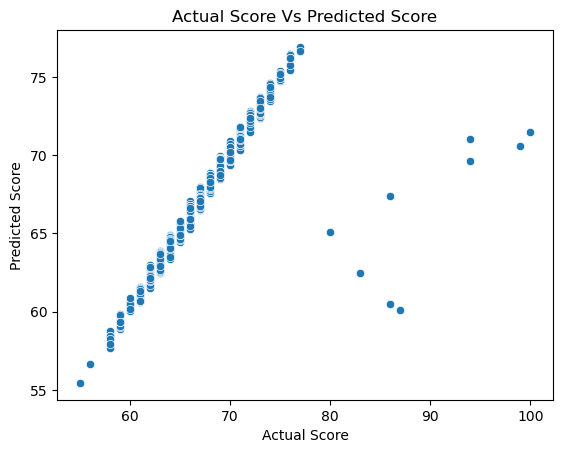

In [65]:
# Scattered PLot of Actual Scored Vs Predicted Score

sns.scatterplot(x= y_test , y = y_pred )
plt.xlabel("Actual Score")
plt.ylabel("Predicted Score")
plt.title("Actual Score Vs Predicted Score")